In [2]:
import pandas as pd
import numpy as np

# ==========================================
# STAGE 1: Data Ingestion
# ==========================================
print("--- Stage 1: Data Ingestion ---")

# Load datasets into Pandas DataFrames
# Assuming the CSV files are in the same directory as your script
deliveries_df = pd.read_csv("data/deliveries.csv")
matches_df = pd.read_csv("data/matches.csv")

# Inspect shape, columns, and data types
print(f"Deliveries shape: {deliveries_df.shape}")
print(f"Matches shape: {matches_df.shape}")
print("\nDeliveries Columns:", list(deliveries_df.columns))
print("Matches Columns:", list(matches_df.columns))


# ==========================================
# STAGE 2: Data Cleaning & Validation
# ==========================================
print("\n--- Stage 2: Data Cleaning & Validation ---")

# Check for missing values (filtering to only show columns that actually have missing data)
missing_deliveries = deliveries_df.isnull().sum()
print("Missing values in Deliveries:\n", missing_deliveries[missing_deliveries > 0])

missing_matches = matches_df.isnull().sum()
print("\nMissing values in Matches:\n", missing_matches[missing_matches > 0])

# Validate match IDs alignment between datasets
delivery_match_ids = set(deliveries_df['match_id'].unique())
matches_ids = set(matches_df['id'].unique())

unmatched_ids = delivery_match_ids - matches_ids
if len(unmatched_ids) == 0:
    print("\nValidation Passed: All match IDs in deliveries perfectly align with matches metadata.")
else:
    print(f"\nWarning: Found {len(unmatched_ids)} match IDs in deliveries without matching metadata.")


# ==========================================
# STAGE 3: Data Transformation
# ==========================================
print("\n--- Stage 3: Data Transformation ---")

# 1. Create new columns: Total runs per ball
# standard IPL datasets usually have 'batsman_runs' and 'extra_runs'
if 'total_runs' not in deliveries_df.columns:
    if 'batsman_runs' in deliveries_df.columns and 'extra_runs' in deliveries_df.columns:
        deliveries_df['total_runs'] = deliveries_df['batsman_runs'] + deliveries_df['extra_runs']
        print("Calculated and created 'total_runs' column.")

# 2. Standardize columns: Ensure consistent naming (snake_case, lowercased, stripped spaces)
deliveries_df.columns = [col.strip().lower().replace(" ", "_") for col in deliveries_df.columns]
matches_df.columns = [col.strip().lower().replace(" ", "_") for col in matches_df.columns]
print("Standardized column names to snake_case.")

# 3. Merge datasets
# Merging ball-by-ball delivery data with match metadata
merged_df = deliveries_df.merge(
    matches_df, 
    left_on="match_id", 
    right_on="id", 
    how="inner",
    suffixes=('_delivery', '_match') # In case of overlapping column names (like 'umpire1')
)

print(f"\nMerge successful! Unified DataFrame shape: {merged_df.shape}")

# Save the transformed dataset as a checkpoint
merged_df.to_csv("data/cleaned_merged_ipl_data.csv", index=False)
print("Saved transformed data to 'cleaned_merged_ipl_data.csv'")
# The merged_df is now ready for Stage 4

--- Stage 1: Data Ingestion ---
Deliveries shape: (260920, 17)
Matches shape: (1095, 20)

Deliveries Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
Matches Columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

--- Stage 2: Data Cleaning & Validation ---
Missing values in Deliveries:
 extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

Missing values in Matches:
 city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64


Loading cleaned dataset...


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\3630196808.py:5: DtypeWarning: Columns (0: season, 1: method) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/cleaned_merged_ipl_data.csv")



--- Task 1: Total Runs per Match ---
   match_id  total_match_runs
0    335982               304
1    335983               447
2    335984               261
3    335985               331
4    335986               222


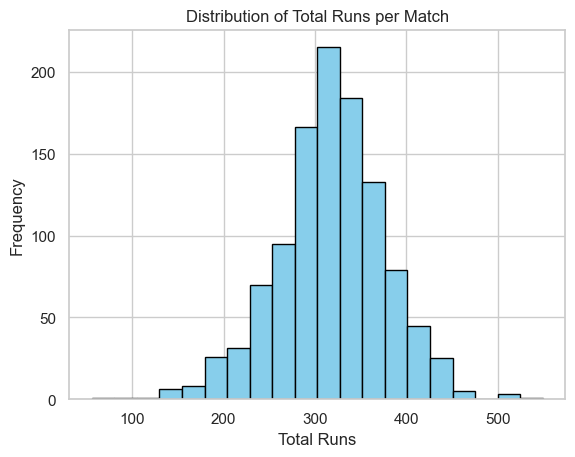

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading cleaned dataset...")
df = pd.read_csv("data/cleaned_merged_ipl_data.csv")

print("\n--- Task 1: Total Runs per Match ---")

# Group by the unique match ID and sum up the total_runs for that match
runs_per_match = df.groupby('match_id')['total_runs'].sum().reset_index()

# Rename the column for better clarity in our final reports
runs_per_match.rename(columns={'total_runs': 'total_match_runs'}, inplace=True)

# Display the first few rows to verify
print(runs_per_match.head())

# Set visual style
sns.set_theme(style="whitegrid")

# Plotting the distribution of match scores
plt.hist(runs_per_match['total_match_runs'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Runs per Match')
plt.xlabel('Total Runs')
plt.ylabel('Frequency')
plt.savefig('task_1_runs_distribution.png')


--- Task 2: Runs per Team per Match ---
   match_id                 batting_team  total_runs
0    335982        Kolkata Knight Riders         222
1    335982  Royal Challengers Bangalore          82
2    335983          Chennai Super Kings         240
3    335983              Kings XI Punjab         207
4    335984             Delhi Daredevils         132


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1248109431.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='total_runs', y='batting_team', data=team_runs_per_match, palette='Set2')


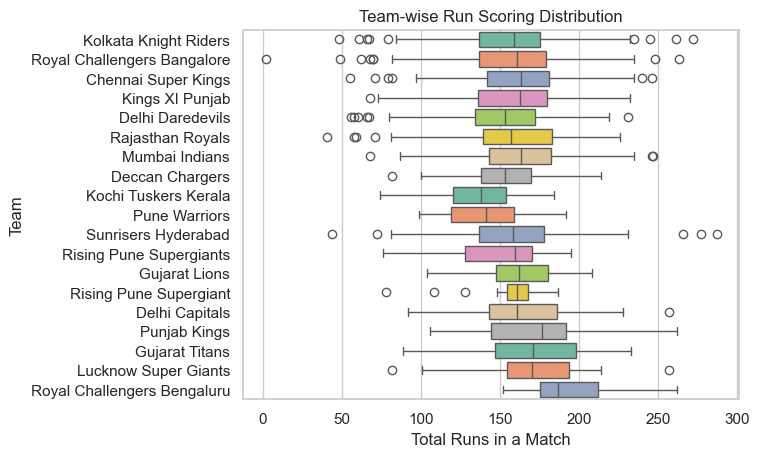

In [4]:
print("\n--- Task 2: Runs per Team per Match ---")
team_runs_per_match = df.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
print(team_runs_per_match.head())

sns.set_theme(style="whitegrid")
# Visualizing team scoring consistency
sns.boxplot(x='total_runs', y='batting_team', data=team_runs_per_match, palette='Set2')
plt.title('Team-wise Run Scoring Distribution')
plt.xlabel('Total Runs in a Match')
plt.ylabel('Team')
plt.savefig('task_2_team_boxplot.png')


--- Task 3: Top 10 Batters ---
             batter  batsman_runs
631         V Kohli          8014
512        S Dhawan          6769
477       RG Sharma          6630
147       DA Warner          6567
546        SK Raina          5536
374        MS Dhoni          5243
30   AB de Villiers          5181
124        CH Gayle          4997
501      RV Uthappa          4954
282      KD Karthik          4843


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1852933086.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batsman_runs', y='batter', data=top_10_batters, palette='viridis')


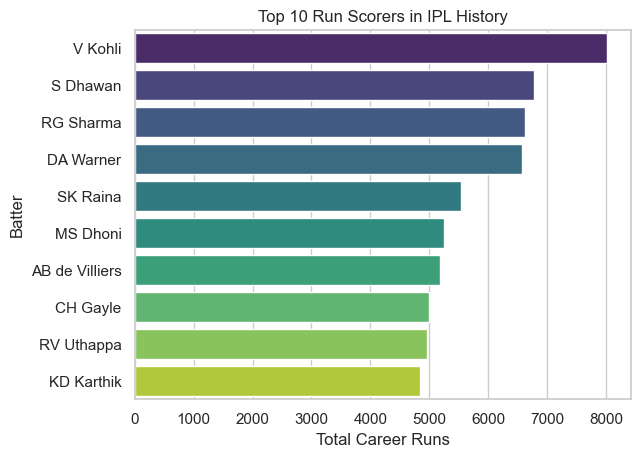

In [5]:

print("\n--- Task 3: Top 10 Batters ---")
top_10_batters = df.groupby('batter')['batsman_runs'].sum().reset_index()
top_10_batters = top_10_batters.sort_values(by='batsman_runs', ascending=False).head(10)
print(top_10_batters)

sns.set_theme(style="whitegrid")
# Ranking the top 10 batters
sns.barplot(x='batsman_runs', y='batter', data=top_10_batters, palette='viridis')
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Career Runs')
plt.ylabel('Batter')
plt.savefig('task_3_top_batters.png')


--- Task 4: Strike Rate of Batters ---
              batter  batsman_runs  balls_faced  strike_rate
234  J Fraser-McGurk           330          141       234.04
652         WG Jacks           230          131       175.57
433          PD Salt           653          372       175.54
39        AD Russell          2488         1423       174.84
617          TM Head           772          444       173.87
606         T Stubbs           405          233       173.82
612         TH David           659          387       170.28
105      BCJ Cutting           238          141       168.79
208        H Klaasen           993          590       168.31
85   Ashutosh Sharma           189          113       167.26


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1744165957.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='strike_rate', y='batter', data=top_strike_rates, palette='magma')


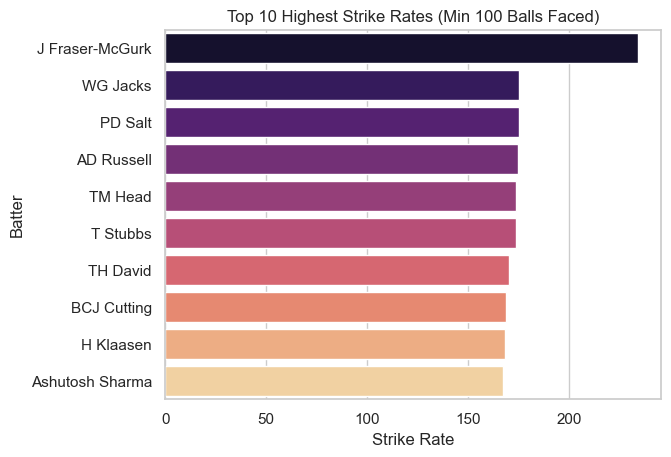

In [6]:

print("\n--- Task 4: Strike Rate of Batters ---")
# Logic: Wides do not count as a ball faced by the batter
valid_balls = df[df['extras_type'] != 'wides']
balls_faced = valid_balls.groupby('batter')['ball'].count().reset_index()
balls_faced.rename(columns={'ball': 'balls_faced'}, inplace=True)

batter_runs = df.groupby('batter')['batsman_runs'].sum().reset_index()

# Merge runs and balls faced
strike_rate_df = pd.merge(batter_runs, balls_faced, on='batter')
strike_rate_df['strike_rate'] = (strike_rate_df['batsman_runs'] / strike_rate_df['balls_faced']) * 100
strike_rate_df['strike_rate'] = strike_rate_df['strike_rate'].round(2)

# Filter for batters with > 100 balls faced to filter out tail-enders with inflated stats
top_strike_rates = strike_rate_df[strike_rate_df['balls_faced'] > 100].sort_values(by='strike_rate', ascending=False).head(10)
print(top_strike_rates)

sns.set_theme(style="whitegrid")
sns.barplot(x='strike_rate', y='batter', data=top_strike_rates, palette='magma')
plt.title('Top 10 Highest Strike Rates (Min 100 Balls Faced)')
plt.xlabel('Strike Rate')
plt.ylabel('Batter')
plt.savefig('task_4_strike_rates.png')


--- Task 5: Top 10 Bowlers by Economy ---
              bowler  total_runs  legal_balls_bowled  overs_bowled  \
2         A Chandila         245                 234     39.000000   
281        MJ Clarke          72                  66     11.000000   
443  SMSM Senanayake         211                 192     32.000000   
442       SM Pollock         307                 276     46.000000   
473    Sohail Tanvir         275                 247     41.166667   
173         IS Sodhi         204                 181     30.166667   
7           A Kumble        1089                 965    160.833333   
147       GD McGrath         366                 324     54.000000   
343   PD Collingwood         101                  89     14.833333   
141       FH Edwards         160                 140     23.333333   

     economy_rate  
2            6.28  
281          6.55  
443          6.59  
442          6.67  
473          6.68  
173          6.76  
7            6.77  
147          6.78  
343   

C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\2956439079.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='economy_rate', y='bowler', data=top_economy, palette='coolwarm')


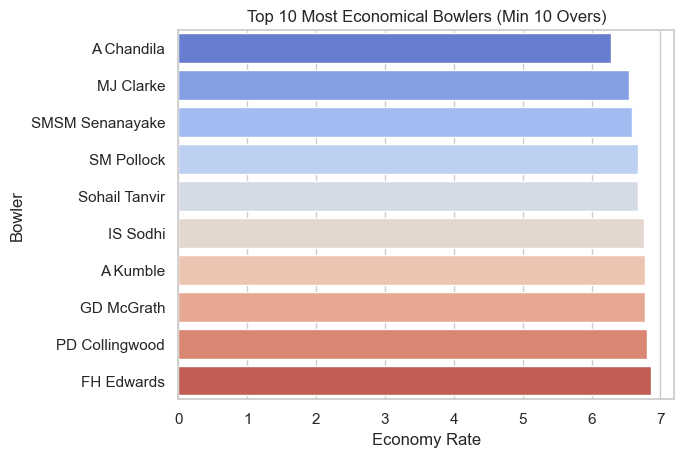

In [7]:

print("\n--- Task 5: Top 10 Bowlers by Economy ---")
# Logic: Legal balls exclude wides and no-balls
bowler_runs = df.groupby('bowler')['total_runs'].sum().reset_index() 
legal_balls = df[~df['extras_type'].isin(['wides', 'noballs'])].groupby('bowler')['ball'].count().reset_index()
legal_balls.rename(columns={'ball': 'legal_balls_bowled'}, inplace=True)

economy_df = pd.merge(bowler_runs, legal_balls, on='bowler')
economy_df['overs_bowled'] = economy_df['legal_balls_bowled'] / 6
economy_df['economy_rate'] = (economy_df['total_runs'] / economy_df['overs_bowled']).round(2)

# Filter for bowlers who have bowled at least 10 overs (60 balls) to get realistic stats
top_economy = economy_df[economy_df['legal_balls_bowled'] >= 60].sort_values(by='economy_rate', ascending=True).head(10)
print(top_economy)

sns.set_theme(style="whitegrid")
sns.barplot(x='economy_rate', y='bowler', data=top_economy, palette='coolwarm')
plt.title('Top 10 Most Economical Bowlers (Min 10 Overs)')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.savefig('task_5_bowler_economy.png')


--- Task 6: Most Consistent Batters ---
           batter  batsman_runs  matches_played  average_runs
289      KL Rahul          4689             122         38.43
473    RD Gaikwad          2380              65         36.62
542      SE Marsh          2489              69         36.07
147     DA Warner          6567             184         35.69
124      CH Gayle          4997             141         35.44
365     ML Hayden          1107              32         34.59
352    MEK Hussey          1977              58         34.09
242    JC Buttler          3583             106         33.80
188  F du Plessis          4571             138         33.12
631       V Kohli          8014             244         32.84


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1243501805.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_runs', y='batter', data=consistent_batters, palette='flare')


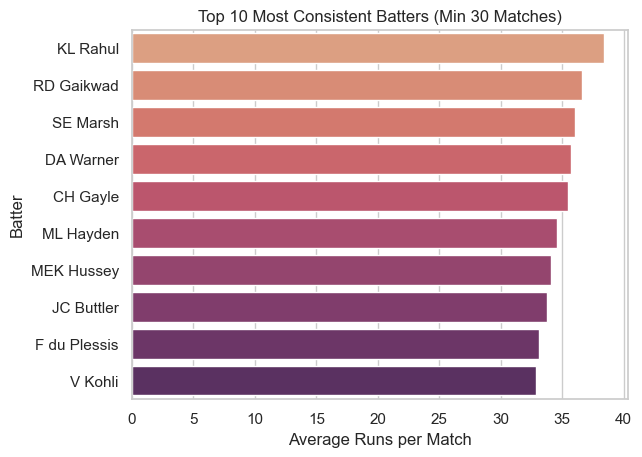

In [8]:

print("\n--- Task 6: Most Consistent Batters ---")
# Consistency measured by average runs per match (total runs / total matches played)
matches_played = df.groupby('batter')['match_id'].nunique().reset_index()
matches_played.rename(columns={'match_id': 'matches_played'}, inplace=True)

# Using batter_runs calculated previously in Task 4, or recalculating:
batter_runs = df.groupby('batter')['batsman_runs'].sum().reset_index()

consistency_df = pd.merge(batter_runs, matches_played, on='batter')
consistency_df['average_runs'] = (consistency_df['batsman_runs'] / consistency_df['matches_played']).round(2)

# Filter for a minimum of 30 matches played to ensure a reliable sample size
consistent_batters = consistency_df[consistency_df['matches_played'] >= 30].sort_values(by='average_runs', ascending=False).head(10)
print(consistent_batters)

sns.set_theme(style="whitegrid")
# Visualizing batting consistency (Average runs per match)
sns.barplot(x='average_runs', y='batter', data=consistent_batters, palette='flare')
plt.title('Top 10 Most Consistent Batters (Min 30 Matches)')
plt.xlabel('Average Runs per Match')
plt.ylabel('Batter')
plt.savefig('task_6_consistency.png')


--- Task 7: Highest Individual Score in a Match ---
       match_id          batter  batsman_runs
5302     598027        CH Gayle           175
2        335982     BB McCullum           158
14108   1304112       Q de Kock           140
7528     829795  AB de Villiers           133
11583   1216510        KL Rahul           132
15383   1370352    Shubman Gill           129
8359     980987  AB de Villiers           129
4687     548372        CH Gayle           128
10149   1136602         RR Pant           128
2237     419137         M Vijay           127


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\158553452.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batsman_runs', y='batter', data=top_individual_scores, palette='crest')


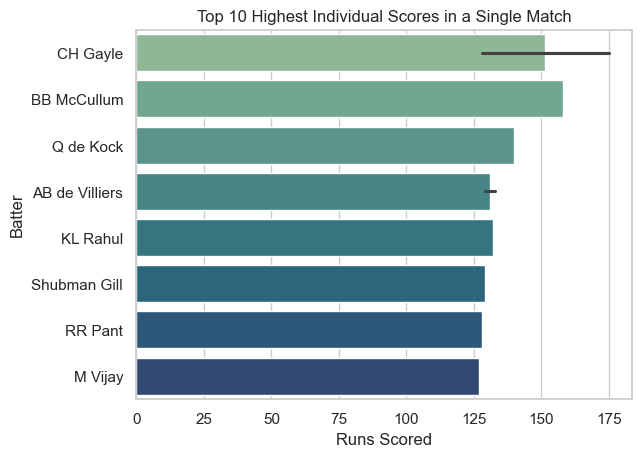

In [9]:
print("\n--- Task 7: Highest Individual Score in a Match ---")
# Group by both match and batter to find the highest score in a single inning
highest_score_df = df.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index()
top_individual_scores = highest_score_df.sort_values(by='batsman_runs', ascending=False).head(10)
print(top_individual_scores)

sns.set_theme(style="whitegrid")

# Visualizing the highest individual scores in a single match
sns.barplot(x='batsman_runs', y='batter', data=top_individual_scores, palette='crest')
plt.title('Top 10 Highest Individual Scores in a Single Match')
plt.xlabel('Runs Scored')
plt.ylabel('Batter')
plt.savefig('task_7_highest_scores.png')


--- Task 8: Boundary Analysis ---
Total 4s hit in IPL history: 29850
Total 6s hit in IPL history: 13051

Top 10 Players by Total Boundaries:
             batter  total_boundaries
532         V Kohli               981
437        S Dhawan               921
126       DA Warner               899
409       RG Sharma               880
109        CH Gayle               767
462        SK Raina               710
25   AB de Villiers               667
427      RV Uthappa               663
243      KD Karthik               627
323        MS Dhoni               615


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\3898641919.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_boundaries', y='batter', data=top_boundary_hitters, palette='rocket')


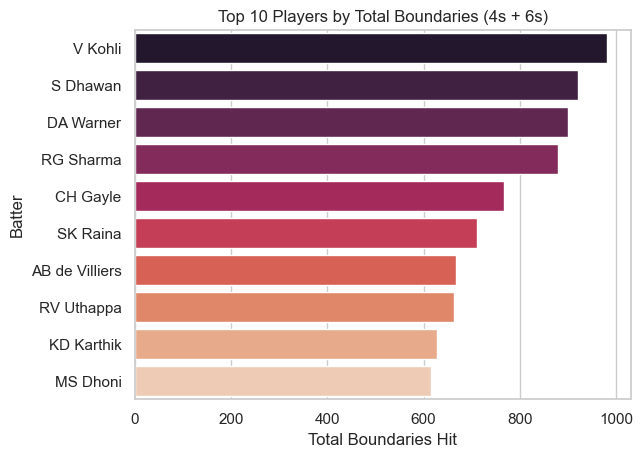

In [10]:

print("\n--- Task 8: Boundary Analysis ---")
# Overall totals
total_4s = len(df[df['batsman_runs'] == 4])
total_6s = len(df[df['batsman_runs'] == 6])
print(f"Total 4s hit in IPL history: {total_4s}")
print(f"Total 6s hit in IPL history: {total_6s}\n")

# Top players by boundaries
boundaries_df = df[df['batsman_runs'].isin([4, 6])]
top_boundary_hitters = boundaries_df.groupby('batter')['batsman_runs'].count().reset_index()
top_boundary_hitters.rename(columns={'batsman_runs': 'total_boundaries'}, inplace=True)
top_boundary_hitters = top_boundary_hitters.sort_values(by='total_boundaries', ascending=False).head(10)
print("Top 10 Players by Total Boundaries:")
print(top_boundary_hitters)

sns.set_theme(style="whitegrid")

# Visualizing top boundary hitters
sns.barplot(x='total_boundaries', y='batter', data=top_boundary_hitters, palette='rocket')
plt.title('Top 10 Players by Total Boundaries (4s + 6s)')
plt.xlabel('Total Boundaries Hit')
plt.ylabel('Batter')
plt.savefig('task_8_boundary_hitters.png')


--- Task 9: Boundary Percentage ---
             batter  batsman_runs  runs_from_boundaries  boundary_percentage
561       SP Narine          1534                1238.0                80.70
39       AD Russell          2488                1938.0                77.89
433         PD Salt           653                 500.0                76.57
124        CH Gayle          4997                3786.0                75.77
570   ST Jayasuriya           768                 570.0                74.22
427  P Simran Singh           756                 558.0                73.81
662     YBK Jaiswal          1607                1180.0                73.43
32     AC Gilchrist          2069                1508.0                72.89
633        V Sehwag          2728                1972.0                72.29
431     PC Valthaty           505                 364.0                72.08


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\906396640.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='boundary_percentage', y='batter', data=top_boundary_pct, palette='YlOrBr')


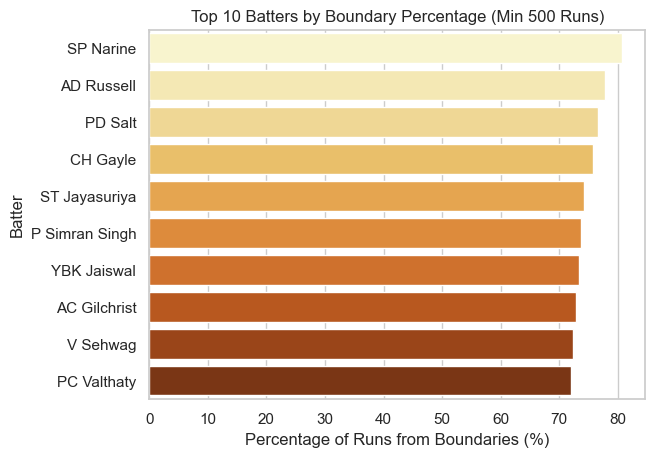

In [11]:
batter_runs = df.groupby('batter')['batsman_runs'].sum().reset_index()
print("\n--- Task 9: Boundary Percentage ---")
# Calculate the total amount of RUNS a player has scored exclusively from 4s and 6s
boundary_runs = df[df['batsman_runs'].isin([4, 6])].groupby('batter')['batsman_runs'].sum().reset_index()
boundary_runs.rename(columns={'batsman_runs': 'runs_from_boundaries'}, inplace=True)

# Merge back with their total runs
boundary_pct_df = pd.merge(batter_runs, boundary_runs, on='batter', how='left').fillna(0)
boundary_pct_df['boundary_percentage'] = ((boundary_pct_df['runs_from_boundaries'] / boundary_pct_df['batsman_runs']) * 100).round(2)

# Filter for batters with at least 500 total runs
top_boundary_pct = boundary_pct_df[boundary_pct_df['batsman_runs'] >= 500].sort_values(by='boundary_percentage', ascending=False).head(10)
print(top_boundary_pct)

sns.set_theme(style="whitegrid")

# Visualizing players with the highest percentage of runs from boundaries
sns.barplot(x='boundary_percentage', y='batter', data=top_boundary_pct, palette='YlOrBr')
plt.title('Top 10 Batters by Boundary Percentage (Min 500 Runs)')
plt.xlabel('Percentage of Runs from Boundaries (%)')
plt.ylabel('Batter')
plt.savefig('task_9_boundary_percentage.png')


--- Task 10: Dot Ball Analysis ---
Total dot balls bowled: 90438

Top 10 Bowlers by Dot Balls Bowled:
              bowler  dot_balls_bowled
70           B Kumar              1632
436        SP Narine              1569
348         R Ashwin              1552
341        PP Chawla              1325
159  Harbhajan Singh              1263
188        JJ Bumrah              1228
366        RA Jadeja              1216
511        YS Chahal              1194
482         UT Yadav              1186
8           A Mishra              1185


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1754880074.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dot_balls_bowled', y='bowler', data=top_dot_bowlers, palette='mako')


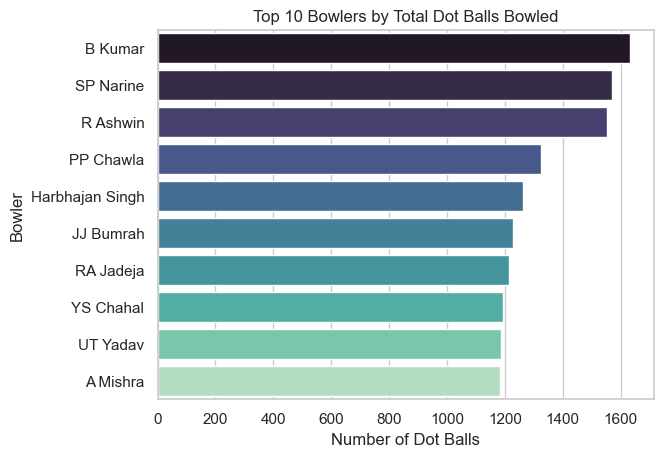

In [12]:

print("\n--- Task 10: Dot Ball Analysis ---")
# Count dot balls where NO runs were scored off the delivery (total_runs == 0)
dot_balls = df[df['total_runs'] == 0]
print(f"Total dot balls bowled: {len(dot_balls)}\n")

# Identify bowlers with the most dot balls
top_dot_bowlers = dot_balls.groupby('bowler')['ball'].count().reset_index()
top_dot_bowlers.rename(columns={'ball': 'dot_balls_bowled'}, inplace=True)
top_dot_bowlers = top_dot_bowlers.sort_values(by='dot_balls_bowled', ascending=False).head(10)
print("Top 10 Bowlers by Dot Balls Bowled:")
print(top_dot_bowlers)

sns.set_theme(style="whitegrid")

# Visualizing bowlers with the most dot balls
sns.barplot(x='dot_balls_bowled', y='bowler', data=top_dot_bowlers, palette='mako')
plt.title('Top 10 Bowlers by Total Dot Balls Bowled')
plt.xlabel('Number of Dot Balls')
plt.ylabel('Bowler')
plt.savefig('task_10_dot_balls.png')


--- Task 11: Runs per Over Analysis ---
Average Runs Scored in Each Over (Ranked by Highest):
    over  total_runs   ball  avg_runs_per_over
19    19       17765   9998              10.66
18    18       19076  11583               9.88
17    17       19559  12318               9.53
16    16       19012  12685               8.99
15    15       18472  12879               8.61
14    14       18149  13024               8.36
5      5       18528  13494               8.24
4      4       18565  13560               8.21
3      3       18415  13575               8.14
13    13       17634  13124               8.06
2      2       17895  13597               7.90
12    12       17205  13222               7.81
11    11       17076  13261               7.73
10    10       16779  13289               7.58
8      8       16639  13396               7.45
9      9       16353  13354               7.35
7      7       15981  13430               7.14
1      1       16163  13773               7.04
6      6    

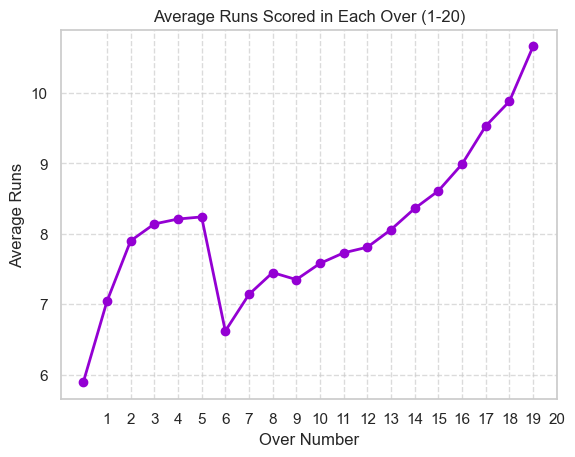

In [13]:

print("\n--- Task 11: Runs per Over Analysis ---")
# Calculate total runs scored in each specific over (1 through 20)
over_runs = df.groupby('over')['total_runs'].sum().reset_index()
over_balls = df.groupby('over')['ball'].count().reset_index()

# Merge to calculate the average runs per over (Economy rate of that specific over)
over_analysis = pd.merge(over_runs, over_balls, on='over')
# Divide balls by 6 to get total number of actual overs bowled
over_analysis['avg_runs_per_over'] = (over_analysis['total_runs'] / (over_analysis['ball'] / 6)).round(2)

high_scoring_overs = over_analysis.sort_values(by='avg_runs_per_over', ascending=False)
print("Average Runs Scored in Each Over (Ranked by Highest):")
print(high_scoring_overs.head(20))

sns.set_theme(style="whitegrid")

# Visualizing the scoring trend across 20 overs
plt.plot(over_analysis['over'], over_analysis['avg_runs_per_over'], marker='o', color='darkviolet', linewidth=2)
plt.title('Average Runs Scored in Each Over (1-20)')
plt.xlabel('Over Number')
plt.ylabel('Average Runs')
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('task_11_runs_per_over.png')


--- Task 12: Powerplay Performance (Overs 1-6) ---
Total runs scored in all Powerplays: 118056

Best Teams in Powerplay (Average Runs per Match):
                   batting_team  total_runs  match_id  avg_pp_runs_per_match
17  Royal Challengers Bengaluru         993        15                  66.20
4                 Gujarat Lions        1818        30                  60.60
2                Delhi Capitals        5358        91                  58.88
12                 Punjab Kings        3231        56                  57.70
18          Sunrisers Hyderabad       10170       182                  55.88


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1768759413.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_pp_runs_per_match', y='batting_team', data=best_pp_teams, palette='autumn')


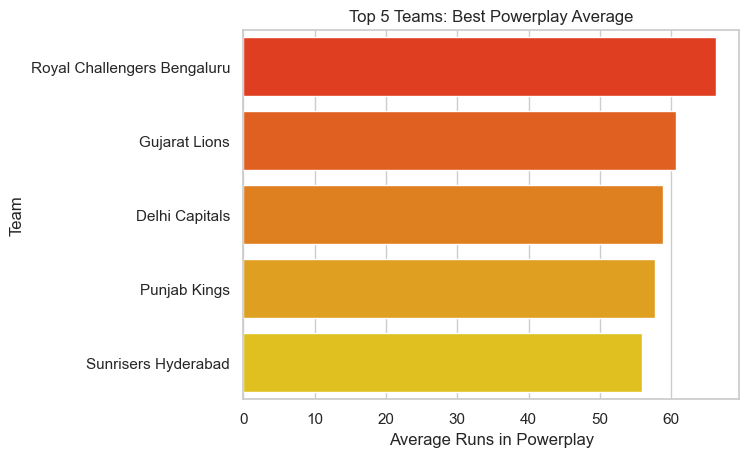

In [14]:

print("\n--- Task 12: Powerplay Performance (Overs 1-6) ---")
# Filter for overs 1 through 6
powerplay_df = df[df['over'] <= 6]
pp_total_runs = powerplay_df['total_runs'].sum()
print(f"Total runs scored in all Powerplays: {pp_total_runs}")

# Best teams in powerplay (Calculate average powerplay score per match)
pp_team_runs = powerplay_df.groupby('batting_team')['total_runs'].sum().reset_index()
pp_team_matches = powerplay_df.groupby('batting_team')['match_id'].nunique().reset_index()

pp_team_analysis = pd.merge(pp_team_runs, pp_team_matches, on='batting_team')
pp_team_analysis['avg_pp_runs_per_match'] = (pp_team_analysis['total_runs'] / pp_team_analysis['match_id']).round(2)
best_pp_teams = pp_team_analysis.sort_values(by='avg_pp_runs_per_match', ascending=False).head(5)
print("\nBest Teams in Powerplay (Average Runs per Match):")
print(best_pp_teams)

sns.set_theme(style="whitegrid")

# Visualizing the highest-scoring teams in the Powerplay
sns.barplot(x='avg_pp_runs_per_match', y='batting_team', data=best_pp_teams, palette='autumn')
plt.title('Top 5 Teams: Best Powerplay Average')
plt.xlabel('Average Runs in Powerplay')
plt.ylabel('Team')
plt.savefig('task_12_powerplay_teams.png')


--- Task 13: Death Overs Performance (Overs 16-20) ---
Total runs scored in all Death Overs: 75412

Best Teams in Death Overs (Average Runs per Match):
                   batting_team  total_runs  match_id  \
17  Royal Challengers Bengaluru         611        13   
5                Gujarat Titans        1823        44   
9          Lucknow Super Giants        1718        42   
15      Rising Pune Supergiants         443        11   
0           Chennai Super Kings        9061       228   

    avg_death_runs_per_match  
17                     47.00  
5                      41.43  
9                      40.90  
15                     40.27  
0                      39.74  

Most Destructive Batters in Death Overs (Min 50 balls faced):
              batter  total_runs_scored  balls_faced  strike_rate
529         T Stubbs                233           85       274.12
24    AB de Villiers               1421          635       223.78
301       MA Agarwal                188           86     

C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\1054432956.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='strike_rate', y='batter', data=best_death_batters, palette='winter')


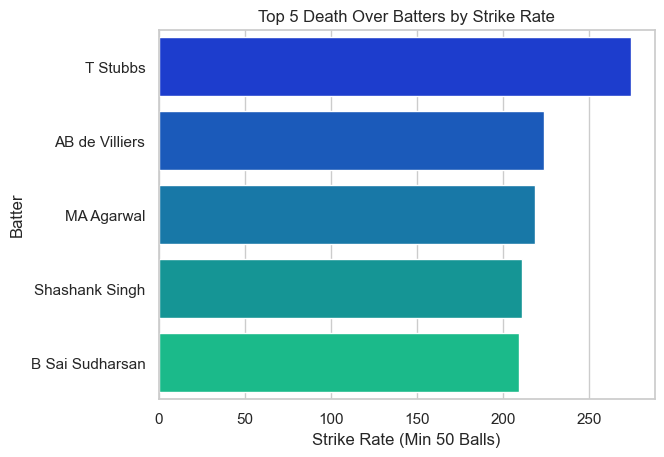

In [15]:
print("\n--- Task 13: Death Overs Performance (Overs 16-20) ---")
# Filter for overs 16 through 20
death_overs_df = df[df['over'] >= 16]
death_total_runs = death_overs_df['total_runs'].sum()
print(f"Total runs scored in all Death Overs: {death_total_runs}")

# Best teams in death overs (Calculate average death over score per match)
death_team_runs = death_overs_df.groupby('batting_team')['total_runs'].sum().reset_index()
death_team_matches = death_overs_df.groupby('batting_team')['match_id'].nunique().reset_index()

death_team_analysis = pd.merge(death_team_runs, death_team_matches, on='batting_team')
death_team_analysis['avg_death_runs_per_match'] = (death_team_analysis['total_runs'] / death_team_analysis['match_id']).round(2)
best_death_teams = death_team_analysis.sort_values(by='avg_death_runs_per_match', ascending=False).head(5)
print("\nBest Teams in Death Overs (Average Runs per Match):")
print(best_death_teams)

# Best batters in death overs (Based on strike rate, minimum 50 balls faced)
death_batter_sr = death_overs_df.groupby('batter').agg(
    total_runs_scored=('batsman_runs', 'sum'), 
    balls_faced=('ball', 'count')
).reset_index()
death_batter_sr['strike_rate'] = ((death_batter_sr['total_runs_scored'] / death_batter_sr['balls_faced']) * 100).round(2)

best_death_batters = death_batter_sr[death_batter_sr['balls_faced'] > 50].sort_values(by='strike_rate', ascending=False).head(5)
print("\nMost Destructive Batters in Death Overs (Min 50 balls faced):")
print(best_death_batters)

sns.set_theme(style="whitegrid")

# Visualizing the most destructive finishers (Overs 16-20)
sns.barplot(x='strike_rate', y='batter', data=best_death_batters, palette='winter')
plt.title('Top 5 Death Over Batters by Strike Rate')
plt.xlabel('Strike Rate (Min 50 Balls)')
plt.ylabel('Batter')
plt.savefig('task_13_death_batters.png')


--- Task 14: Run Distribution per Inning ---
   inning  total_runs
0       1      181274
1       2      166196


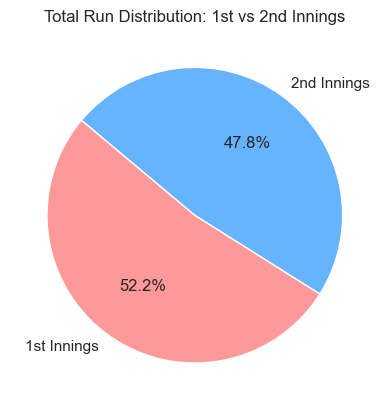

In [16]:
print("\n--- Task 14: Run Distribution per Inning ---")
# Compare total runs scored in 1st innings vs 2nd innings
inning_runs = df.groupby('inning')['total_runs'].sum().reset_index()

# Filter out super overs (innings 3, 4, etc.) to keep the analysis clean
standard_innings = inning_runs[inning_runs['inning'].isin([1, 2])]
print(standard_innings)

# Comparing total runs across standard innings
labels = ['1st Innings', '2nd Innings']
plt.pie(standard_innings['total_runs'], labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title('Total Run Distribution: 1st vs 2nd Innings')
plt.savefig('task_14_innings_distribution.png')


--- Task 15: Toss Impact Analysis ---
Percentage of matches won by the team that won the toss: 50.83%


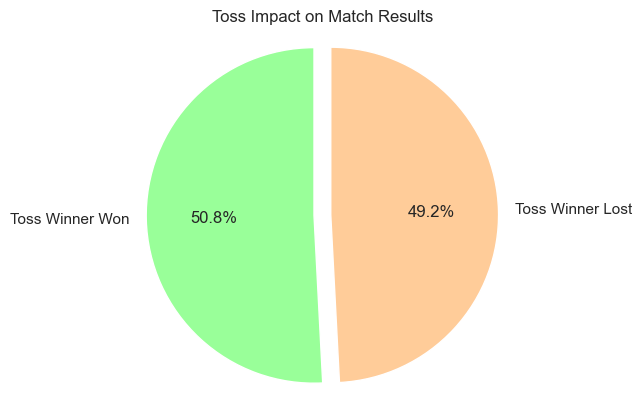

In [17]:
print("\n--- Task 15: Toss Impact Analysis ---")
# We need to drop duplicates on match_id because the merged df has 260,000 rows
# We only need 1 row per match to check the toss outcome
unique_matches = df.drop_duplicates(subset=['match_id']).copy()

# Filter out matches with no winner (No Result / Abandoned)
valid_matches = unique_matches.dropna(subset=['winner', 'toss_winner'])

# Check if toss_winner is the same as the match winner
toss_and_match_winner = valid_matches[valid_matches['toss_winner'] == valid_matches['winner']]

toss_advantage_pct = (len(toss_and_match_winner) / len(valid_matches)) * 100
print(f"Percentage of matches won by the team that won the toss: {toss_advantage_pct:.2f}%")

# Visualizing the percentage of matches won by the toss winner
labels = ['Toss Winner Won', 'Toss Winner Lost']
sizes = [toss_advantage_pct, 100 - toss_advantage_pct]
colors = ['#99ff99', '#ffcc99']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.1, 0))
plt.title('Toss Impact on Match Results')
plt.axis('equal') # Ensures pie is a circle
plt.savefig('task_15_toss_impact.png')


--- Task 16: Player of Match Contribution ---
Percentage of times the Player of the Match was the highest run scorer: 45.50%


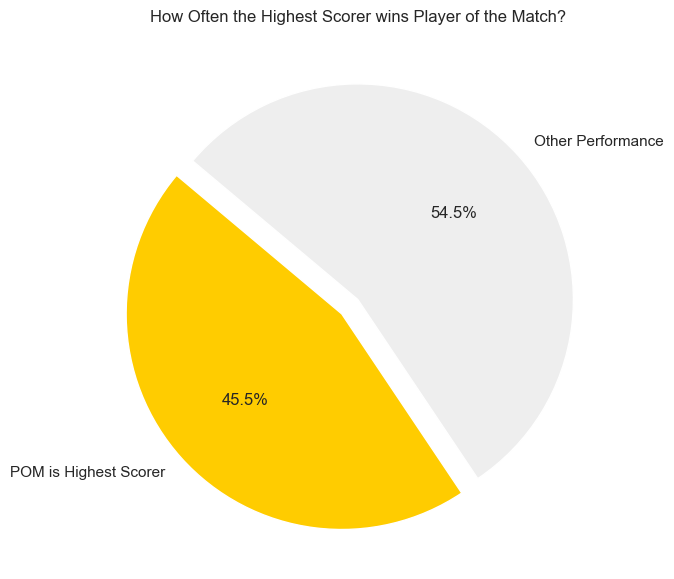

In [18]:
matches_df = df.drop_duplicates(subset=['match_id']).rename(columns={'match_id': 'id'})
print("\n--- Task 16: Player of Match Contribution ---")
# 1. Extract unique match data directly from the merged df
pom_df = df[['match_id', 'player_of_match']].drop_duplicates().dropna()

# 2. Find the highest run scorer for every match
match_batters = df.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index()
highest_scorers = match_batters.loc[match_batters.groupby('match_id')['batsman_runs'].idxmax()]

# 3. Merge and calculate
pom_impact = pd.merge(highest_scorers, pom_df, on='match_id')
pom_impact['is_highest_scorer'] = pom_impact['batter'] == pom_impact['player_of_match']

pom_highest_scorer_pct = (pom_impact['is_highest_scorer'].sum() / len(pom_impact)) * 100
print(f"Percentage of times the Player of the Match was the highest run scorer: {pom_highest_scorer_pct:.2f}%")

# Visualizing POM and highest scorer correlation
labels = ['POM is Highest Scorer', 'Other Performance']
sizes = [pom_highest_scorer_pct, 100 - pom_highest_scorer_pct]
colors = ['#ffcc00', '#eeeeee']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.1, 0))
plt.title('How Often the Highest Scorer wins Player of the Match?')
plt.savefig('task_16_pom_impact.png')


--- Task 17: Venue-wise Analysis ---
Venue Analysis (Top 5 Most Played Venues):
                                       venue  total_matches  total_runs  \
0                               Eden Gardens             77       23658   
1                           Wankhede Stadium             73       23407   
2                      M Chinnaswamy Stadium             65       20263   
3                           Feroz Shah Kotla             60       18421   
4  Rajiv Gandhi International Stadium, Uppal             49       14888   

   avg_runs_per_match  
0              307.25  
1              320.64  
2              311.74  
3              307.02  
4              303.84  


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\873517254.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_runs_per_match', y='venue', data=venue_analysis.head(5), palette='plasma')


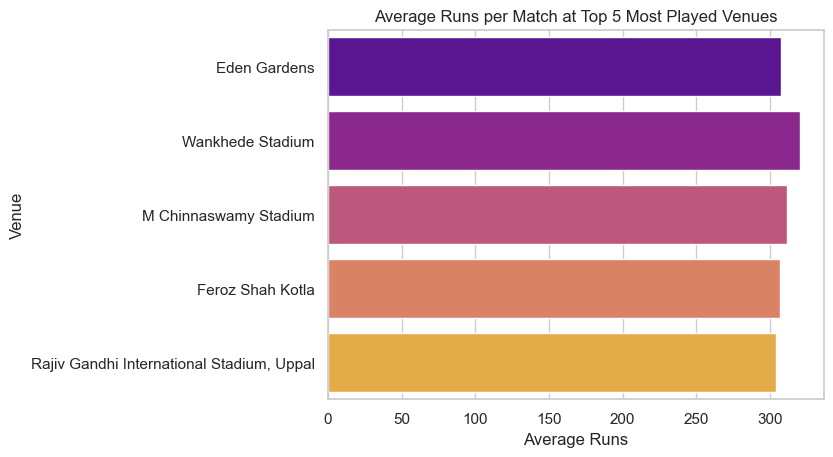

In [19]:
print("\n--- Task 17: Venue-wise Analysis ---")
venue_matches = matches_df['venue'].value_counts().reset_index()
venue_matches.columns = ['venue', 'total_matches']

venue_runs = df.groupby('venue')['total_runs'].sum().reset_index()
venue_analysis = pd.merge(venue_matches, venue_runs, on='venue')
venue_analysis['avg_runs_per_match'] = (venue_analysis['total_runs'] / venue_analysis['total_matches']).round(2)

print("Venue Analysis (Top 5 Most Played Venues):")
print(venue_analysis.head())

sns.set_theme(style="whitegrid")

# Visualizing top 5 most played venues by average score
# Corrected the x-axis column name to 'avg_runs_per_match'
sns.barplot(x='avg_runs_per_match', y='venue', data=venue_analysis.head(5), palette='plasma')
plt.title('Average Runs per Match at Top 5 Most Played Venues')
plt.xlabel('Average Runs')
plt.ylabel('Venue')
plt.savefig('task_17_venue_scores.png')


--- Task 18: City-wise Scoring Trends ---
Highest Scoring Cities (Minimum 10 Matches):
          city  total_matches  total_runs  avg_runs_per_match
11   Bengaluru             29       10449              360.31
15  Dharamsala             13        4412              339.38
18      Rajkot             10        3333              333.30
10   Ahmedabad             36       11917              331.03
0       Mumbai            173       56817              328.42


C:\Users\mgho3013\AppData\Local\Temp\ipykernel_14660\2305126283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_runs_per_match', y='city', data=high_scoring_cities.head(10), palette='viridis')


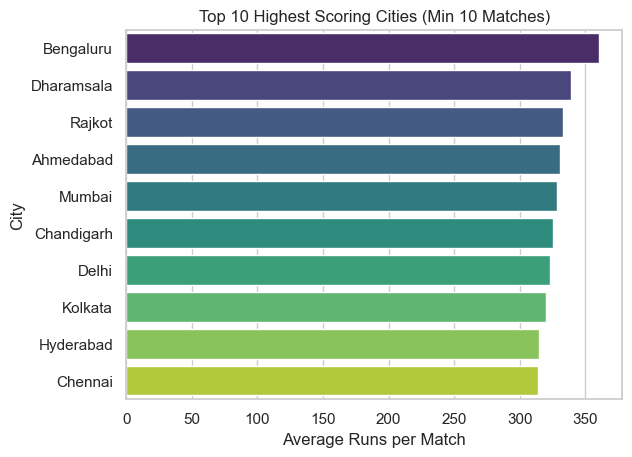

In [21]:
matches_df = df.drop_duplicates(subset=['match_id']).rename(columns={'match_id': 'id'})
print("\n--- Task 18: City-wise Scoring Trends ---")
city_matches = matches_df['city'].value_counts().reset_index()
city_matches.columns = ['city', 'total_matches']

city_runs = df.groupby('city')['total_runs'].sum().reset_index()
city_analysis = pd.merge(city_matches, city_runs, on='city')
city_analysis['avg_runs_per_match'] = (city_analysis['total_runs'] / city_analysis['total_matches']).round(2)

# Filter for a minimum of 10 matches to avoid skewed data from one-off high scoring games
high_scoring_cities = city_analysis[city_analysis['total_matches'] >= 10].sort_values('avg_runs_per_match', ascending=False)
print("Highest Scoring Cities (Minimum 10 Matches):")
print(high_scoring_cities.head())

sns.set_theme(style="whitegrid")

# Visualizing scoring trends in major cities
sns.barplot(x='avg_runs_per_match', y='city', data=high_scoring_cities.head(10), palette='viridis')
plt.title('Top 10 Highest Scoring Cities (Min 10 Matches)')
plt.xlabel('Average Runs per Match')
plt.ylabel('City')
plt.savefig('task_18_city_trends.png')


--- Task 19: Season-wise Run Trends ---
Historical Run Scoring Trends by Season:
     season  total_runs  total_matches  avg_runs_per_match
12  2007/08       17937             58              309.26
13     2009       16353             57              286.89
14  2009/10       18883             60              314.72
0      2011       11678             41              284.83
15     2011        9476             32              296.12
1      2012       22453             74              303.42
2      2013       22602             76              297.39
3      2014       18931             60              315.52
4      2015       18353             59              311.07
5      2016       18862             60              314.37
6      2017       18786             59              318.41
7      2018       18685             57              327.81
16     2018        1216              3              405.33
17     2019       19434             60              323.90
18  2020/21       19416          

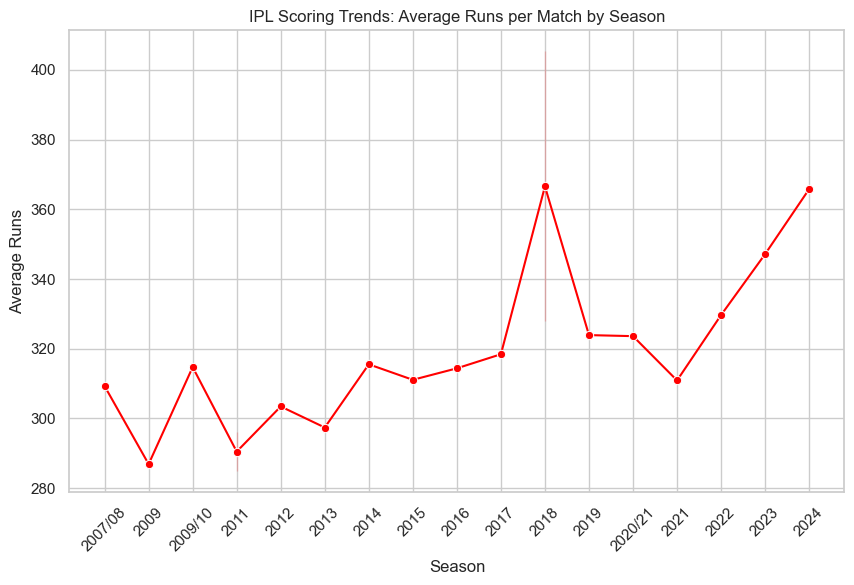

In [22]:
matches_df = df.drop_duplicates(subset=['match_id']).rename(columns={'match_id': 'id'})
print("\n--- Task 19: Season-wise Run Trends ---")
season_runs = df.groupby('season')['total_runs'].sum().reset_index()

# Get unique matches per season
season_matches = df.drop_duplicates(subset=['match_id'])['season'].value_counts().reset_index()
season_matches.columns = ['season', 'total_matches']

season_analysis = pd.merge(season_runs, season_matches, on='season')
season_analysis['avg_runs_per_match'] = (season_analysis['total_runs'] / season_analysis['total_matches']).round(2)
season_analysis['season'] = season_analysis['season'].astype(str)

print("Historical Run Scoring Trends by Season:")
print(season_analysis.sort_values('season'))

sns.set_theme(style="whitegrid")

# Tracking how IPL scoring has changed over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x='season', y='avg_runs_per_match', data=season_analysis.sort_values('season'), marker='o', color='red')
plt.title('IPL Scoring Trends: Average Runs per Match by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(rotation=45)
plt.savefig('task_19_season_trends.png')

Accuracy of determining the winner purely by max runs (excluding D/L method): 99.44%


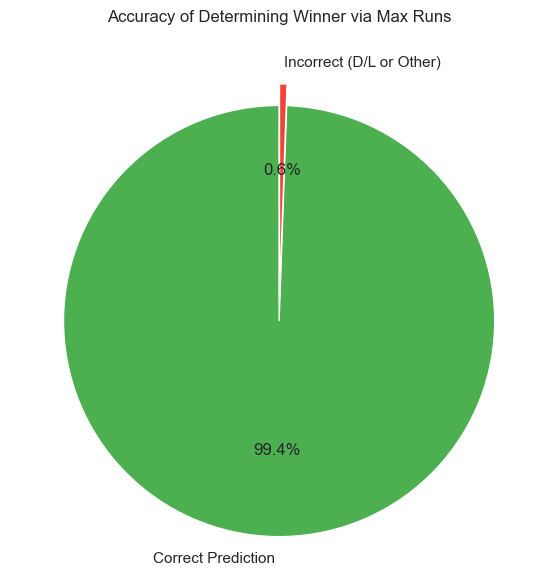

In [23]:
matches_df = df.drop_duplicates(subset=['match_id']).rename(columns={'match_id': 'id'})
match_team_runs = df.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()

# Programmatically find the team with the maximum runs per match
calculated_winners = match_team_runs.loc[match_team_runs.groupby('match_id')['total_runs'].idxmax()]
calculated_winners = calculated_winners.rename(columns={'batting_team': 'calculated_winner'})
actual_winners = df[['match_id', 'winner', 'method']].drop_duplicates()

winner_comparison = pd.merge(calculated_winners[['match_id', 'calculated_winner']], actual_winners, on='match_id')

winner_comparison['match_status'] = winner_comparison['calculated_winner'] == winner_comparison['winner']
matches_without_dls = winner_comparison[winner_comparison['method'] != 'D/L']

accuracy = (matches_without_dls['match_status'].sum() / len(matches_without_dls)) * 100
print(f"Accuracy of determining the winner purely by max runs (excluding D/L method): {accuracy:.2f}%")

# Visualizing the accuracy of the winning team calculation
labels = ['Correct Prediction', 'Incorrect (D/L or Other)']
sizes = [accuracy, 100 - accuracy]
colors = ['#4CAF50', '#F44336']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.1, 0))
plt.title('Accuracy of Determining Winner via Max Runs')
plt.savefig('task_20_prediction_accuracy.png')